# Heart disease ANN notes

I rewrote this notebook to study the heart-disease dataset with a cleaner ANN workflow. The main fix was to stop fitting imputers, encoders, and feature selection on the full dataset before the split.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    make_scorer,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

In [2]:
from pathlib import Path

def first_existing_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    return Path(candidates[0])

data_path = first_existing_path(
    '../data/heart_disease_uci.csv',
    'data/heart_disease_uci.csv',
    'projects/heart-disease-ann/data/heart_disease_uci.csv',
)

df = pd.read_csv(data_path)
print(f'Shape: {df.shape}')
df.head()

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## First look

I kept the original multiclass target `num`, where `0` means no disease and larger values mean more severe disease. The dataset also mixes numeric measurements with categorical clinical labels, so I need a split-safe preprocessing pipeline.

In [3]:
summary = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'dtype': df.dtypes.astype(str),
})
summary

,missing_values,dtype
id,0,int64
age,0,int64
sex,0,object
dataset,0,object
cp,0,object
trestbps,59,float64
chol,30,float64
fbs,90,object
restecg,2,object
thalch,55,float64


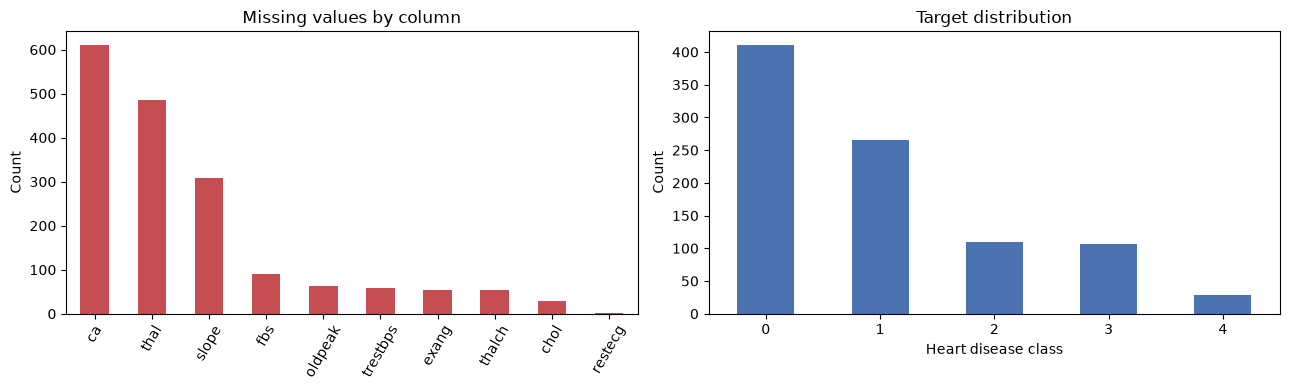

,count
num,
0,411
1,265
2,109
3,107
4,28


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

missing_plot = summary.loc[summary['missing_values'] > 0, 'missing_values'].sort_values(ascending=False)
missing_plot.plot(kind='bar', ax=axes[0], color='#c44e52')
axes[0].set_title('Missing values by column')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=60)

class_counts = df['num'].value_counts().sort_index()
class_counts.plot(kind='bar', ax=axes[1], color='#4c72b0')
axes[1].set_title('Target distribution')
axes[1].set_xlabel('Heart disease class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
class_counts.rename('count').to_frame()

## Split before preprocessing

I drop the patient id because it is just an identifier, not a clinical signal. Everything else stays inside a pipeline so the training folds are the only place where imputation, scaling, encoding, and feature scoring get fitted.

In [5]:
X = df.drop(columns=['num', 'id'])
y = df['num']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocess = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]),
            categorical_features,
        ),
    ]
)

print('Train/validation pool:', X_train_val.shape)
print('Test set:', X_test.shape)
print('Numeric columns:', numeric_features)
print('Categorical columns:', categorical_features)

Train/validation pool: (736, 14)
Test set: (184, 14)
Numeric columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


## Compare a few ANN sizes

I use 4-fold cross-validation on the training portion and rank models by macro F1. That metric matters here because the severe classes are much rarer than class `0`.

In [6]:
def build_pipeline(hidden_layer_sizes):
    return Pipeline([
        ('preprocess', preprocess),
        ('select', SelectKBest(score_func=f_classif, k=20)),
        ('model', MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            alpha=0.0005,
            max_iter=800,
            random_state=RANDOM_STATE,
            solver='adam',
        )),
    ])

architectures = [(16,), (32,), (48, 24), (64, 32), (64, 64)]
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy': 'accuracy',
    'macro_f1': make_scorer(f1_score, average='macro'),
}

records = []
for hidden_layers in architectures:
    result = cross_validate(
        build_pipeline(hidden_layers),
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )
    records.append({
        'hidden_layers': hidden_layers,
        'mean_accuracy': result['test_accuracy'].mean(),
        'mean_macro_f1': result['test_macro_f1'].mean(),
        'std_macro_f1': result['test_macro_f1'].std(),
    })

cv_results = pd.DataFrame(records).sort_values(
    ['mean_macro_f1', 'mean_accuracy'],
    ascending=False,
    ignore_index=True,
)
cv_results

,hidden_layers,mean_accuracy,mean_macro_f1,std_macro_f1
0,"(32,)",0.561141,0.365956,0.024192
1,"(64, 32)",0.544837,0.351297,0.015010
2,"(16,)",0.551630,0.349115,0.027702
3,"(48, 24)",0.539402,0.345943,0.017576
4,"(64, 64)",0.529891,0.337667,0.017287


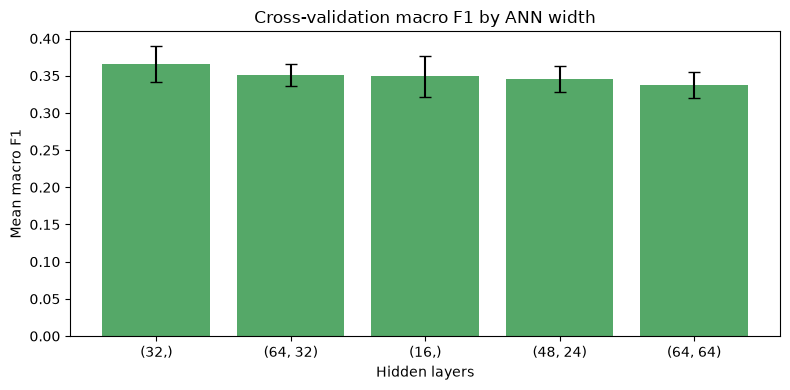

Chosen hidden layers: (32,)


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    cv_results['hidden_layers'].astype(str),
    cv_results['mean_macro_f1'],
    yerr=cv_results['std_macro_f1'],
    color='#55a868',
    capsize=4,
)
ax.set_title('Cross-validation macro F1 by ANN width')
ax.set_xlabel('Hidden layers')
ax.set_ylabel('Mean macro F1')
plt.tight_layout()
plt.show()

best_hidden_layers = tuple(cv_results.loc[0, 'hidden_layers'])
print('Chosen hidden layers:', best_hidden_layers)

The `(32,)` network wins the cross-validation comparison in my run. The gap is not huge, but it is the most stable choice among the candidates I tried.

In [8]:
final_pipeline = build_pipeline(best_hidden_layers)
final_pipeline.fit(X_train_val, y_train_val)

y_pred = final_pipeline.predict(X_test)

metrics_df = pd.DataFrame([
    {
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
    }
]).round(3)

metrics_df

,accuracy,macro_precision,macro_recall,macro_f1
0,0.554,0.424,0.37,0.379


In [9]:
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True, zero_division=0)).T
report_df.round(3)

,precision,recall,f1-score,support
0,0.768,0.768,0.768,82.000
1,0.517,0.585,0.549,53.000
2,0.125,0.091,0.105,22.000
3,0.208,0.238,0.222,21.000
4,0.500,0.167,0.250,6.000
accuracy,0.554,0.554,0.554,0.554
macro avg,0.424,0.370,0.379,184.000
weighted avg,0.546,0.554,0.547,184.000


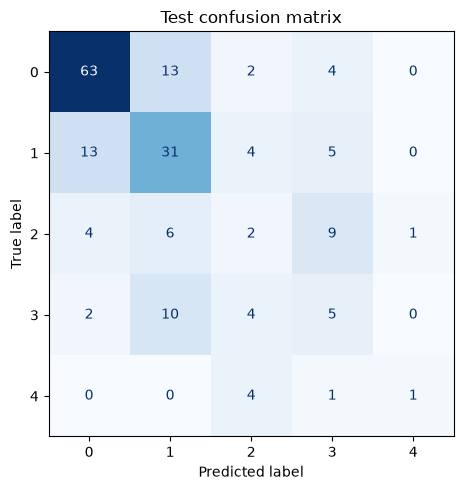

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Test confusion matrix')
plt.tight_layout()
plt.show()

In [11]:
selector = final_pipeline.named_steps['select']
feature_names = final_pipeline.named_steps['preprocess'].get_feature_names_out()
selected_scores = pd.DataFrame({
    'feature': feature_names[selector.get_support()],
    'anova_score': selector.scores_[selector.get_support()],
}).sort_values('anova_score', ascending=False, ignore_index=True)

selected_scores.head(10)

,feature,anova_score
0,cat__cp_asymptomatic,58.598276
1,num__oldpeak,39.527406
2,cat__exang_False,36.768655
3,cat__exang_True,36.768655
4,cat__dataset_Hungary,35.206438
5,num__thalch,34.193856
6,cat__cp_atypical angina,33.415472
7,num__age,25.805807
8,cat__thal_normal,22.092682
9,cat__dataset_Switzerland,21.129954


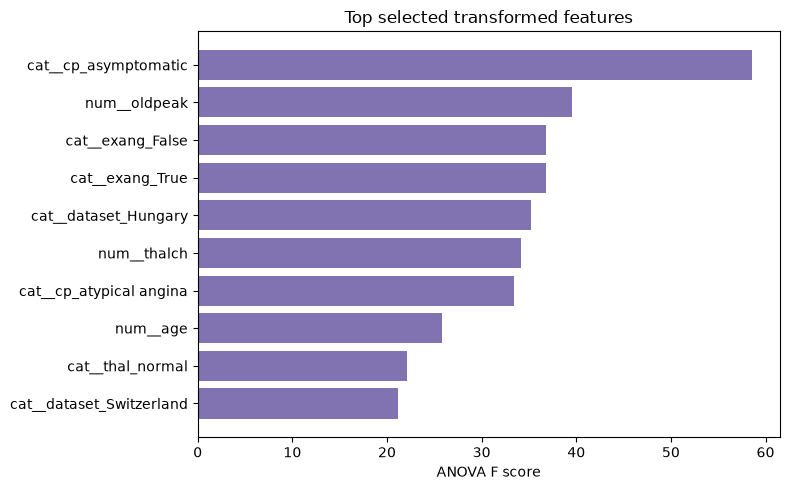

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = selected_scores.head(10).sort_values('anova_score')
ax.barh(plot_df['feature'], plot_df['anova_score'], color='#8172b2')
ax.set_title('Top selected transformed features')
ax.set_xlabel('ANOVA F score')
plt.tight_layout()
plt.show()

## What I learned

In the saved run, the test accuracy is about `0.55` and the macro F1 is about `0.38`. The model handles classes `0` and `1` much better than the rarer severe classes, so the biggest problem now is class imbalance and limited minority examples rather than preprocessing mistakes.